In [23]:
import numpy as np
import pandas as pd
import scipy.io as sio

import os
os.chdir(r'D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing')
print(os.getcwd())

data = sio.loadmat('ring_circular_FSR_FWHM_results.mat')

results = data['results']

def read_entry(results, tag):
    r = results[tag][0,0]
    return {
        "FSR_nm": float(r["FSR_nm"][0,0]),
        "FSR_Hz": float(r["FSR_Hz"][0,0]),
        "FSR_Hz_calc": float(r["FSR_Hz_calculated"][0,0]),
        "FWHM_nm": float(r["FWHM_nm"][0,0]),
        "FWHM_Hz": float(r["FWHM_Hz"][0,0]),
        "FWHM_Hz_calc": float(r["FWHM_Hz_calculated"][0,0]),
    }


D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing


In [24]:
results_struct = results[0,0]

tags_60 = [k for k in results_struct.dtype.names if k.startswith("R60")]
df_60 = pd.DataFrame([read_entry(results_struct, k) | {"tag": k} for k in tags_60])
df_60 = df_60.set_index("tag")


FSR_nm          float64
FSR_Hz          float64
FSR_Hz_calc     float64
FWHM_nm         float64
FWHM_Hz         float64
FWHM_Hz_calc    float64
gap             float64
dtype: object
(5, 7)
           FSR_nm        FSR_Hz   FSR_Hz_calc   FWHM_nm       FWHM_Hz  \
tag                                                                     
R60G100  3.974590  4.963067e+11  4.402870e+11  1.137646  1.420577e+11   
R60G200  3.976981  4.966053e+11  4.402870e+11  0.792284  9.893247e+10   
R60G300  3.978261  4.967652e+11  4.402870e+11  0.539465  6.736299e+10   
R60G600  3.980198  4.970071e+11  4.402870e+11  0.172450  2.153376e+10   
R60G800  3.980469  4.970409e+11  4.402870e+11  0.087426  1.091689e+10   

         FWHM_Hz_calc    gap  
tag                           
R60G100  1.680913e+11  100.0  
R60G200  1.157862e+11  200.0  
R60G300  7.852752e+10  300.0  
R60G600  2.338380e+10  600.0  
R60G800  1.024581e+10  800.0  


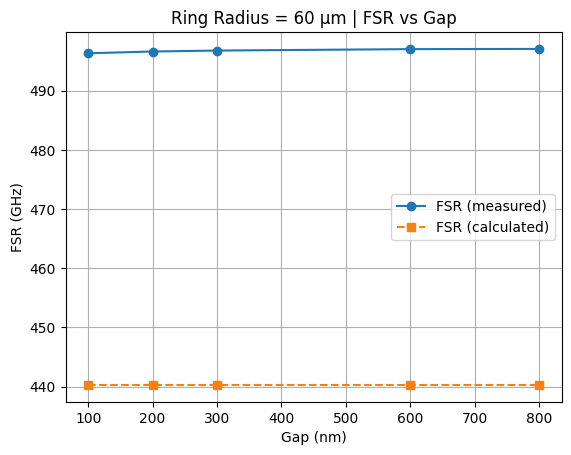

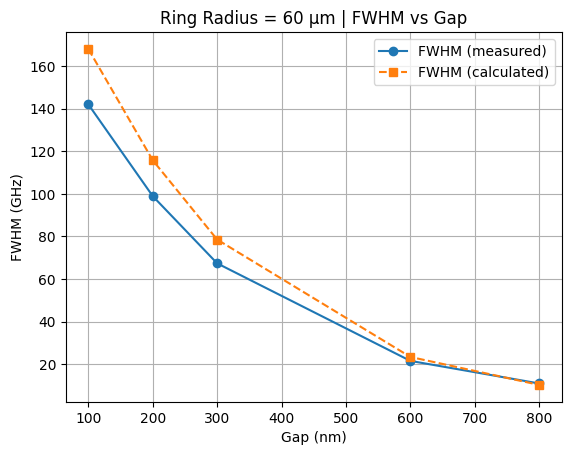

In [ ]:
import matplotlib.pyplot as plt

df = df_60.copy()
df["gap"] = df.index.to_series().str.extract(r"G(\d+)", expand=False).astype(float)
print(df.dtypes)

print(df.shape)
print(df)

# convert Hz → GHz
df["FSR_GHz"]       = df["FSR_Hz"] / 1e9
df["FSR_GHz_calc"]  = df["FSR_Hz_calc"] / 1e9
df["FWHM_GHz"]      = df["FWHM_Hz"] / 1e9
df["FWHM_GHz_calc"] = df["FWHM_Hz_calc"] / 1e9

# -------- FSR plot --------
plt.figure(dpi=100)
plt.plot(df["gap"],df["FSR_GHz"],  "o-", label="FSR (measured)")
plt.plot(df["gap"],df["FSR_GHz_calc"],  "s--", label="FSR (calculated)")
plt.ylabel("FSR (GHz)")
plt.xlabel("Gap (nm)")
plt.title("Ring Radius = 100 µm | FSR vs Gap")
plt.legend()
plt.grid(True)
plt.show()

# -------- FWHM plot --------
plt.figure(dpi=100)
plt.plot(df["gap"],df["FWHM_GHz"],"o-", label="FWHM (measured)")
plt.plot(df["gap"],df["FWHM_GHz_calc"], "s--", label="FWHM (calculated)")
plt.ylabel("FWHM (GHz)")
plt.xlabel("Gap (nm)")
plt.title("Ring Radius = 60 µm | FWHM vs Gap")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
df["FSR_err_GHz"]  = df["FSR_GHz_calc"]  - df["FSR_GHz"]
df["FWHM_err_GHz"] = df["FWHM_GHz_calc"] - df["FWHM_GHz"]

df["FSR_err_pct"]  = 100 * df["FSR_err_GHz"]  / df["FSR_GHz"]
df["FWHM_err_pct"] = 100 * df["FWHM_err_GHz"] / df["FWHM_GHz"]

avg_FSR_err_GHz   = df["FSR_err_GHz"].mean()
avg_FSR_err_pct   = df["FSR_err_pct"].mean()

avg_FWHM_err_GHz  = df["FWHM_err_GHz"].mean()
avg_FWHM_err_pct  = df["FWHM_err_pct"].mean()

print(f"Avg FSR error  = {avg_FSR_err_GHz:.3f} GHz ({avg_FSR_err_pct:.2f} %)")
print(f"Avg FWHM error = {avg_FWHM_err_GHz:.3f} GHz ({avg_FWHM_err_pct:.2f} %)")

# rmse_FSR  = np.sqrt(np.mean(df["FSR_err_GHz"]**2))
# rmse_FWHM = np.sqrt(np.mean(df["FWHM_err_GHz"]**2))

# print(f"FSR RMSE  = {rmse_FSR:.3f} GHz")
# print(f"FWHM RMSE = {rmse_FWHM:.3f} GHz")



Avg FSR error  = -56.458 GHz (-11.37 %)
Avg FWHM error = 11.046 GHz (10.88 %)


FSR_nm          float64
FSR_Hz          float64
FSR_Hz_calc     float64
FWHM_nm         float64
FWHM_Hz         float64
FWHM_Hz_calc    float64
gap             float64
dtype: object
(5, 7)
            FSR_nm        FSR_Hz   FSR_Hz_calc   FWHM_nm       FWHM_Hz  \
tag                                                                      
R100G800  2.386018  2.979419e+11  2.641722e+11  0.060910  7.605863e+09   
R100G600  2.385876  2.979242e+11  2.641722e+11  0.035241  4.400523e+09   
R100G300  2.388556  2.982588e+11  2.641722e+11  0.036064  4.503324e+09   
R100G200  2.387494  2.981262e+11  2.641722e+11  0.036268  4.528844e+09   
R100G100  2.385032  2.978188e+11  2.641722e+11  0.036096  4.507274e+09   

          FWHM_Hz_calc    gap  
tag                            
R100G800  1.000340e+10  800.0  
R100G600  2.280495e+10  600.0  
R100G300  7.529369e+10  300.0  
R100G200  1.090961e+11  200.0  
R100G100  1.521246e+11  100.0  


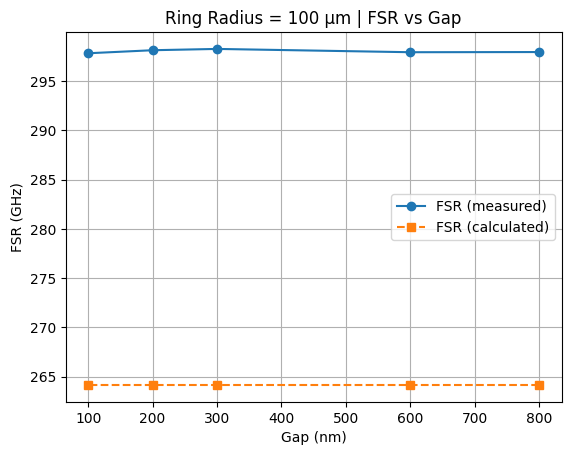

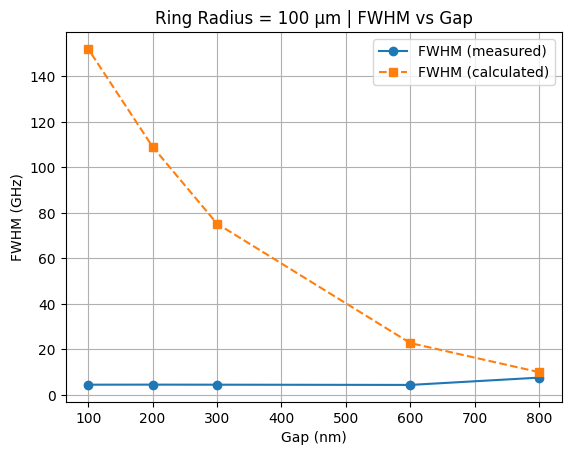

In [28]:
results_struct = results[0,0]

tags_100 = [k for k in results_struct.dtype.names if k.startswith("R100")]
df_100 = pd.DataFrame([read_entry(results_struct, k) | {"tag": k} for k in tags_100])
df_100 = df_100.set_index("tag")

df = df_100.copy()
df["gap"] = df.index.to_series().str.extract(r"G(\d+)", expand=False).astype(float)
print(df.dtypes)

print(df.shape)
print(df)

# convert Hz → GHz
df["FSR_GHz"]       = df["FSR_Hz"] / 1e9
df["FSR_GHz_calc"]  = df["FSR_Hz_calc"] / 1e9
df["FWHM_GHz"]      = df["FWHM_Hz"] / 1e9
df["FWHM_GHz_calc"] = df["FWHM_Hz_calc"] / 1e9

# -------- FSR plot --------
plt.figure(dpi=100)
plt.plot(df["gap"],df["FSR_GHz"],  "o-", label="FSR (measured)")
plt.plot(df["gap"],df["FSR_GHz_calc"],  "s--", label="FSR (calculated)")
plt.ylabel("FSR (GHz)")
plt.xlabel("Gap (nm)")
plt.title("Ring Radius = 100 µm | FSR vs Gap")
plt.legend()
plt.grid(True)
plt.show()

# -------- FWHM plot --------
plt.figure(dpi=100)
plt.plot(df["gap"],df["FWHM_GHz"],"o-", label="FWHM (measured)")
plt.plot(df["gap"],df["FWHM_GHz_calc"], "s--", label="FWHM (calculated)")
plt.ylabel("FWHM (GHz)")
plt.xlabel("Gap (nm)")
plt.title("Ring Radius = 100 µm | FWHM vs Gap")
plt.legend()
plt.grid(True)
plt.show()


In [29]:
df["FSR_err_GHz"]  = df["FSR_GHz_calc"]  - df["FSR_GHz"]
df["FWHM_err_GHz"] = df["FWHM_GHz_calc"] - df["FWHM_GHz"]

df["FSR_err_pct"]  = 100 * df["FSR_err_GHz"]  / df["FSR_GHz"]
df["FWHM_err_pct"] = 100 * df["FWHM_err_GHz"] / df["FWHM_GHz"]

avg_FSR_err_GHz   = df["FSR_err_GHz"].mean()
avg_FSR_err_pct   = df["FSR_err_pct"].mean()

avg_FWHM_err_GHz  = df["FWHM_err_GHz"].mean()
avg_FWHM_err_pct  = df["FWHM_err_pct"].mean()

print(f"Avg FSR error  = {avg_FSR_err_GHz:.3f} GHz ({avg_FSR_err_pct:.2f} %)")
print(f"Avg FWHM error = {avg_FWHM_err_GHz:.3f} GHz ({avg_FWHM_err_pct:.2f} %)")

Avg FSR error  = -33.842 GHz (-11.36 %)
Avg FWHM error = 68.755 GHz (1521.14 %)
